In [22]:
import numpy as np
import pandas as pd


# create some data with null value ( f1, f2, status)
data = {
    'f1': [1, np.nan, 3, 4, 5, 6, 7, 8, 9, 10],
    'f2': [1, 2, 3, 4, np.nan, 6, 7, 8, 9, 10],
    'f3': ['A','A','B','A','B','A','B','A','B','A'],
    'status': ['Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No']
}

df = pd.DataFrame(data)
df

,f1,f2,f3,status
0,1.0,1.0,A,Yes
1,NaN,2.0,A,No
2,3.0,3.0,B,Yes
3,4.0,4.0,A,No
4,5.0,NaN,B,Yes
5,6.0,6.0,A,No
6,7.0,7.0,B,Yes
7,8.0,8.0,A,No
8,9.0,9.0,B,Yes
9,10.0,10.0,A,No


In [23]:
# mean imputations
df['f1'] = df['f1'].fillna(df['f1'].mean())
df['f2'] = df['f2'].fillna(df['f2'].mean())
df

,f1,f2,f3,status
0,1.000000,1.000000,A,Yes
1,5.888889,2.000000,A,No
2,3.000000,3.000000,B,Yes
3,4.000000,4.000000,A,No
4,5.000000,5.555556,B,Yes
5,6.000000,6.000000,A,No
6,7.000000,7.000000,B,Yes
7,8.000000,8.000000,A,No
8,9.000000,9.000000,B,Yes
9,10.000000,10.000000,A,No


In [30]:
pd.get_dummies(df['f3'])

,A,B
0,True,False
1,True,False
2,False,True
3,True,False
4,False,True
5,True,False
6,False,True
7,True,False
8,False,True
9,True,False


In [ ]:
# you need to apply OHE for categorical data
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
test = ohe.fit_transform(df[['f3']])

df = pd.concat([df, pd.DataFrame(test.toarray())], axis=1)


ValueError: Length mismatch: Expected axis has 6 elements, new values have 5 elements

In [25]:
df.columns = ['f1', 'f2', 'f3','status', 'A', 'B']

In [28]:
X =df[['f1', 'f2', 'A', 'B']]
Y= df['status']

In [29]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, Y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [39]:
# imbalance data set
import pandas as pd
import numpy as np
chrun_data = pd.read_csv('/Users/rahultiwari/Documents/02_Freelancing/Hachion_batch/full_stack_ai_engineering/03_Machine_learning/churn_data.csv')
chrun_data.head()

# lets create more columns

chrun_data['Salary'] = np.random.randint(10000, 50000, chrun_data.shape[0])
chrun_data.head()


,Age,MonthlyCharge,Churned,Salary
0,55,60.30,0,25054
1,52,45.55,0,38634
2,65,45.59,0,16560
3,58,54.86,0,22087
4,52,60.75,0,37921


In [40]:
# classification 

# predict willl customer will churn or not


# historical

chrun_data['Churned'].value_counts()

# this is a classification problem : imbalance data

X = chrun_data[['Age', 'MonthlyCharge', 'Salary']]
Y = chrun_data['Churned']

# train test split

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20)


from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=3)

# now you can pass your data to model ==> to get trained

model.fit(x_train, y_train)

# now you can use model to predict

y_pred = model.predict(x_test)

# accuracy

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.95

In [41]:
chrun_data[chrun_data['Churned']==1]

,Age,MonthlyCharge,Churned,Salary
58,37,90.39,1,27149
64,66,92.65,1,47812
70,53,80.89,1,42909
72,59,81.96,1,25123
78,42,84.64,1,29551
94,50,94.63,1,29874
98,55,79.34,1,28709
188,62,84.21,1,39361
191,34,80.01,1,43629
197,35,87.10,1,36753


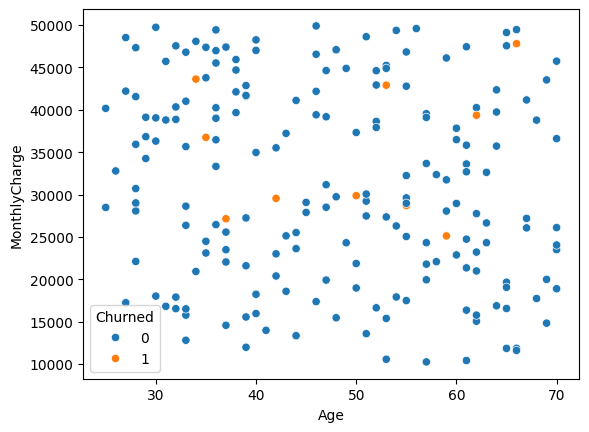

In [43]:
# plot the x_train, y_train

import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(data=chrun_data,x='Age',y='Salary',hue='Churned')
plt.xlabel('Age')
plt.ylabel('MonthlyCharge')
plt.show()

In [50]:
new_customer = pd.DataFrame({
    "Age": [3534534545454],   # 
    "MonthlyCharge": [62],
    "Salary": [2423423423423]
})

new_pred = model.predict(new_customer)
new_pred

array([0])

In [46]:
y_test

162    0
54     0
104    0
39     0
157    0
56     0
57     0
87     0
84     0
164    0
124    0
27     0
34     0
15     0
20     0
136    0
76     0
64     1
198    0
99     0
132    0
35     0
17     0
177    0
75     0
175    0
115    0
150    0
10     0
167    0
128    0
126    0
190    0
165    0
125    0
151    0
88     0
137    0
192    0
195    0
Name: Churned, dtype: int64

In [47]:
x_test

,Age,MonthlyCharge,Salary
162,47,62.68,44633
54,52,48.54,44617
104,61,63.59,35829
39,51,45.71,27478
157,33,44.05,35665
56,38,57.32,45937
57,60,53.53,37830
87,38,62.36,44697
84,33,67.31,26370
164,61,65.21,10425


In [37]:
# pip install imblearn

In [51]:
# oversampling??
from imblearn.over_sampling import SMOTE
smote = SMOTE()

# shape of data before smote
print(X.shape, Y.shape)
# if you check y_distributions it will be imbalanced
print(Y.value_counts())
X_smote, Y_smote = smote.fit_resample(X, Y)


# shape of data after smote
print(X_smote.shape, Y_smote.shape)
# if you check y_distributions it will be balanced. + data tp balanced 
print(Y_smote.value_counts())

# 

(200, 3) (200,)
Churned
0    190
1     10
Name: count, dtype: int64
(380, 3) (380,)
Churned
0    190
1    190
Name: count, dtype: int64


In [52]:
# split it

x_train, x_test, y_train, y_test = train_test_split(X_smote, Y_smote, test_size=0.20)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy_score(y_test, y_pred)

0.7105263157894737

In [56]:
customer_new = pd.DataFrame({
    "Age": [-1],
    "MonthlyCharge": [100],
    "Salary": [10000]
})

model.predict(customer_new)

array([0])

In [59]:
# case 2: check for undersampling

from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler()

# before smote : y_ditributions
print(Y.value_counts())
X_smote, Y_smote = rus.fit_resample(X, Y)
# after smote : y_ditributions
print(Y_smote.value_counts())


# split it

x_train, x_test, y_train, y_test = train_test_split(X_smote, Y_smote, test_size=0.20)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy_score(y_test, y_pred)

Churned
0    190
1     10
Name: count, dtype: int64
Churned
0    10
1    10
Name: count, dtype: int64


0.25

In [62]:
model.predict(x_test)

array([1, 1, 1, 1])

In [63]:
y_test

197    1
42     0
143    0
75     0
Name: Churned, dtype: int64

In [ ]:
# when you have very small data == You cant see the magic of 
# oversampling and undersampling.


# when you are building==>
# you have 3 features 
# you did some analysis
# observations :
# out of 3 only 1 have some relatioship with target( chruned)
# rest 2 is irrelevant. i.e not much contribution in predicting chruned


# cases 
# You want to take some decision in your life
# 1. You will ask for input from me ->

# 2. You will ask for input from me ->

# 3. You will ask for input from me ->

# 4. You will ask for input from me ->

# ==> output 